In [ ]:
from google.colab import files

uploaded = files.upload()

Saving Iris_data.npy to Iris_data.npy
Saving Iris_labels.npy to Iris_labels.npy


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
data = np.load('Iris_data.npy')
labels = np.load('Iris_labels.npy')


In [ ]:
data = np.load('Iris_data.npy')
labels = np.load('Iris_labels.npy')

print("data shape:", data.shape)
print("labels shape:", labels.shape)

feature_names = ["sepal length (cm)", "sepal width (cm)", "petal length (cm)", "petal width (cm)"]

data shape: (150, 4)
labels shape: (150,)


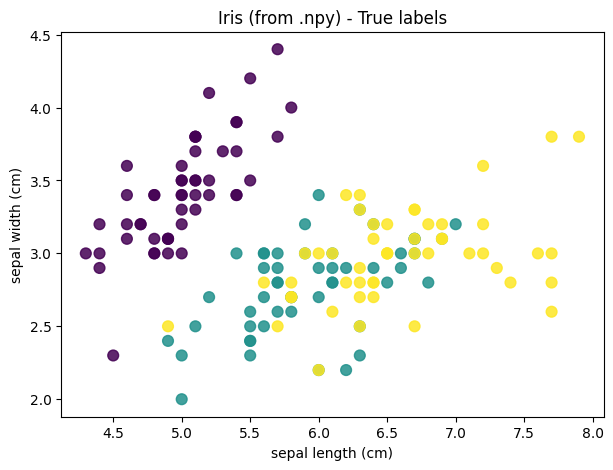

In [ ]:
f1, f2 = 0, 1

plt.figure(figsize=(7,5))
plt.scatter(data[:, f1], data[:, f2], c=labels, cmap="viridis", s=60, alpha=0.85)
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("Iris (from .npy) - True labels")
plt.show()

In [ ]:
def euclidean_distance(centroids, X):
    return np.sqrt(np.sum((X[:, None, :] - centroids[None, :, :])**2, axis=2))

Iteration 0: centroid shift = 3.704310


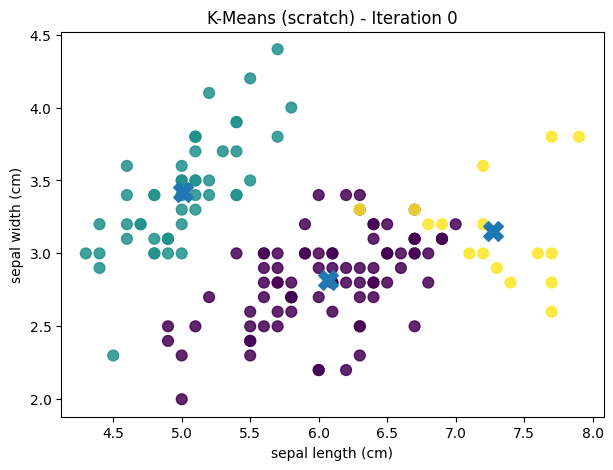

Iteration 1: centroid shift = 0.878681


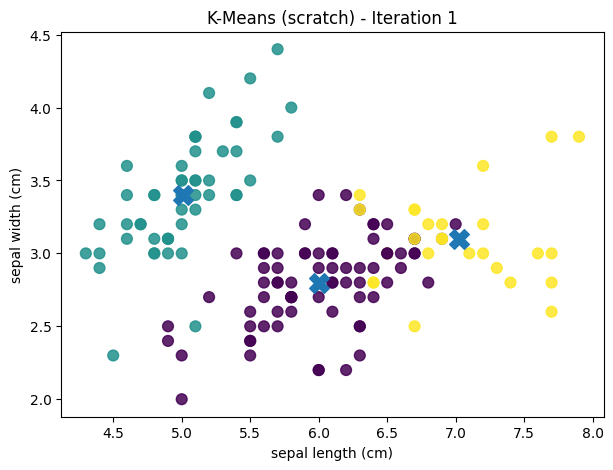

Iteration 2: centroid shift = 0.601464


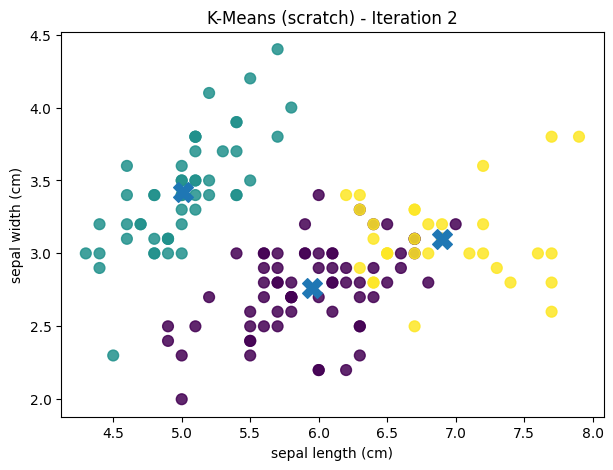

Iteration 3: centroid shift = 0.209322


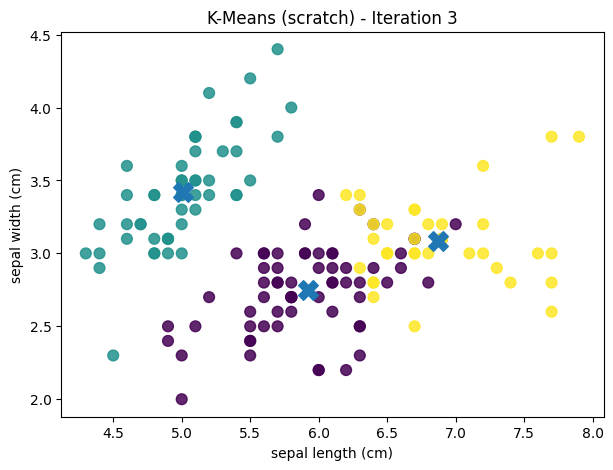

Iteration 4: centroid shift = 0.142857


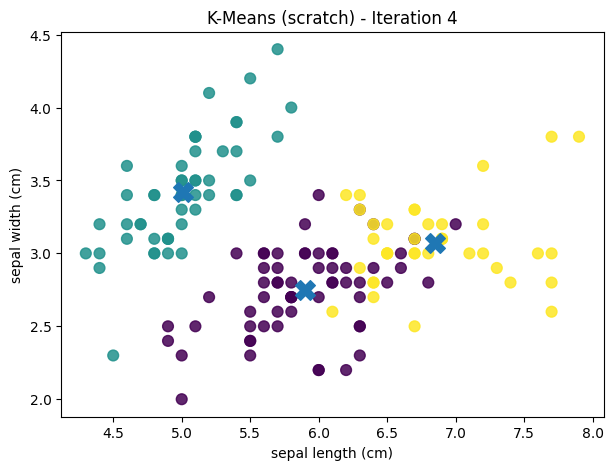

Iteration 5: centroid shift = 0.000000


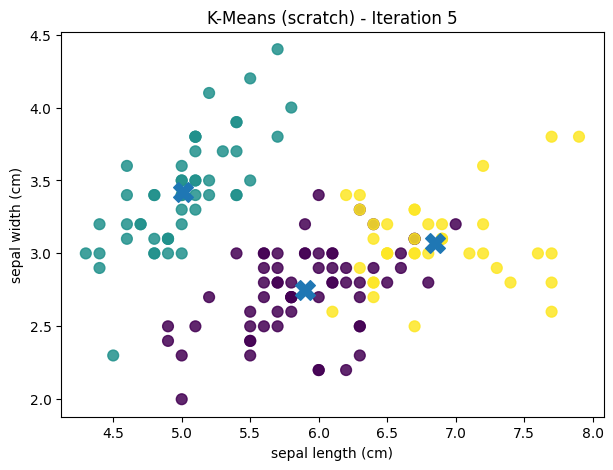

Iteration 6: centroid shift = 0.000000


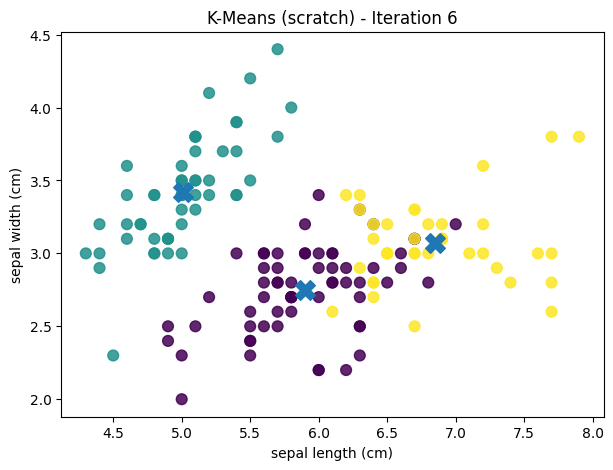

Iteration 7: centroid shift = 0.000000


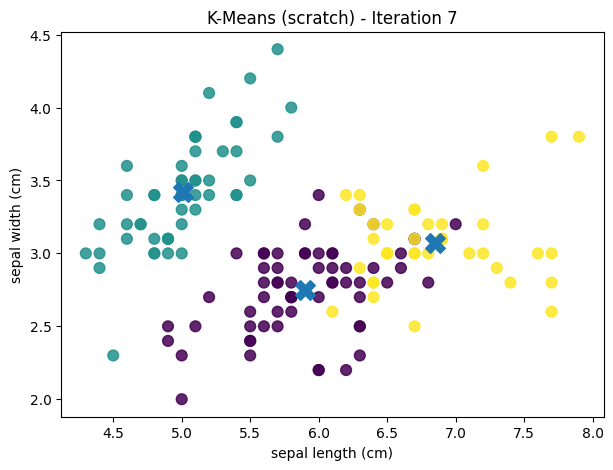

Iteration 8: centroid shift = 0.000000


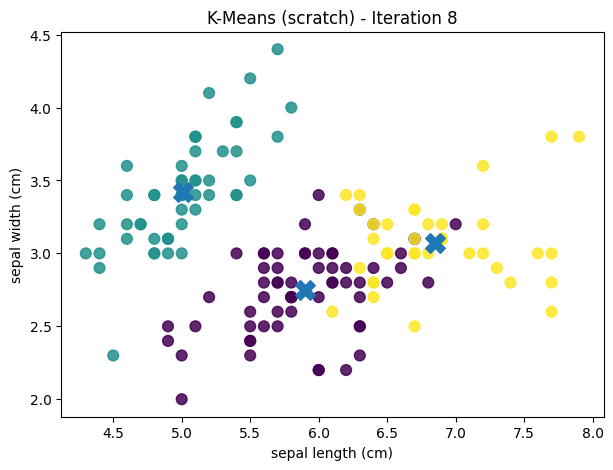

Iteration 9: centroid shift = 0.000000


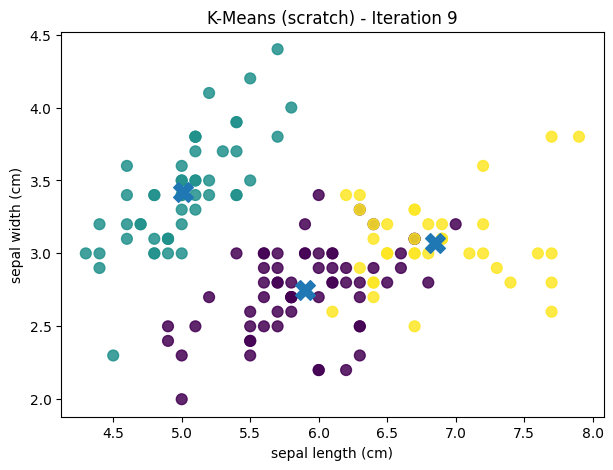

In [ ]:
np.random.seed(42)

k = 3
n_iterations = 10
X = data

centroids = X[np.random.choice(len(X), k, replace=False)]
f1, f2 = 0, 1

for it in range(n_iterations):
    last_centroids = centroids.copy()

    dists = euclidean_distance(centroids, X)
    predicted_label = np.argmin(dists, axis=1)

    new_centroids = np.zeros((k, X.shape[1]))
    for iK in range(k):
        cluster_points = X[predicted_label == iK]
        if len(cluster_points) == 0:
            new_centroids[iK] = X[np.random.choice(len(X))]
        else:
            new_centroids[iK] = cluster_points.mean(axis=0)

    centroids = new_centroids
    shift = np.sum(np.abs(centroids - last_centroids))
    print(f"Iteration {it}: centroid shift = {shift:.6f}")

    plt.figure(figsize=(7,5))
    plt.scatter(X[:, f1], X[:, f2], c=predicted_label, cmap="viridis", s=60, alpha=0.85)
    plt.scatter(centroids[:, f1], centroids[:, f2], marker="X", s=200)
    plt.xlabel(feature_names[f1])
    plt.ylabel(feature_names[f2])
    plt.title(f"K-Means (scratch) - Iteration {it}")
    plt.show()

In [13]:
import numpy as np

def multivariate_gaussian_density(x, mu, sig):
    D = x.shape[0]
    det = np.linalg.det(sig)
    inv = np.linalg.inv(sig)
    norm_const = 1.0 / (((2 * np.pi) ** (D / 2)) * (det ** 0.5))
    diff = x - mu
    expo = -0.5 * (diff @ inv @ diff.T)
    return norm_const * np.exp(expo)

def e_step(X, mu, Sigma, pi):
    """
    X: (N,D), mu: (K,D), Sigma: (D,D,K), pi: (K,)
    returns posteriors gamma: (N,K)
    """
    N = X.shape[0]
    K = mu.shape[0]
    numerators = np.zeros((N, K))

    for n in range(N):
        for k in range(K):
            numerators[n, k] = pi[k] * multivariate_gaussian_density(X[n], mu[k], Sigma[:, :, k])

    denom = np.sum(numerators, axis=1, keepdims=True)
    gamma = numerators / denom
    return gamma

def m_step(X, gamma, eps=1e-6):
    """
    returns updated (pi, mu, Sigma)
    """
    N, D = X.shape
    K = gamma.shape[1]

    Nk = np.sum(gamma, axis=0)  # (K,)

    # mixing coefficients
    pi_new = Nk / N

    # means
    mu_new = np.zeros((K, D))
    for k in range(K):
        w = gamma[:, k:k+1]
        mu_new[k] = (w * X).sum(axis=0) / Nk[k]

    # covariances
    Sigma_new = np.zeros((D, D, K))
    for k in range(K):
        S = np.zeros((D, D))
        for n in range(N):
            diff = (X[n] - mu_new[k]).reshape(D, 1)
            S += gamma[n, k] * (diff @ diff.T)
        Sigma_new[:, :, k] = S / Nk[k] + eps * np.eye(D)

    return pi_new, mu_new, Sigma_new

In [14]:
np.random.seed(42)

g = 3
nIteration = 10
X = data
N, D = X.shape

cluster_centroids = np.zeros((g, D))
g_SD = np.zeros((D, D, g))
g_mix = np.zeros(g)

eps = 1e-6

for k in range(g):
    Xk = X[predicted_label == k]
    Nk = len(Xk)

    if Nk == 0:
        cluster_centroids[k] = X[np.random.choice(N)]
        g_SD[:, :, k] = np.cov(X.T) + eps * np.eye(D)
        g_mix[k] = 1.0 / g
    else:
        cluster_centroids[k] = Xk.mean(axis=0)
        g_SD[:, :, k] = (np.cov(Xk.T) if Nk > 1 else np.cov(X.T)) + eps * np.eye(D)
        g_mix[k] = Nk / N

g_mix = g_mix / g_mix.sum()

print("Initialized GMM from K-Means.")
print("g_mix:", g_mix, "sum =", g_mix.sum())

Initialized GMM from K-Means.
g_mix: [0.41333333 0.33333333 0.25333333] sum = 1.0


In [16]:
for i in range(nIteration):
    # E-Step
    posteriors = e_step(X, cluster_centroids, g_SD, g_mix)

    # M-Step
    g_mix, cluster_centroids, g_SD = m_step(X, posteriors)

    print(f"Iteration {i}", end="\r")

print("\nDone !!")

Iteration 9
Done !!


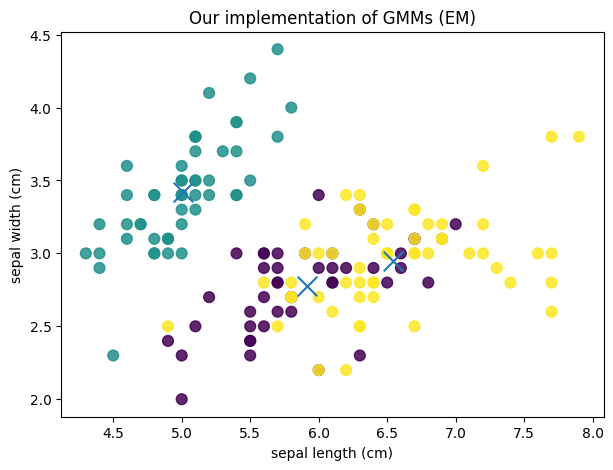

In [17]:
f1, f2 = 0, 1
predicted_label_gmm = np.argmax(posteriors, axis=1)

plt.figure(figsize=(7,5))
plt.scatter(X[:, f1], X[:, f2], c=predicted_label_gmm, cmap="viridis", s=60, alpha=0.85)
plt.scatter(cluster_centroids[:, f1], cluster_centroids[:, f2], marker="x", s=200)
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("Our implementation of GMMs (EM)")
plt.show()

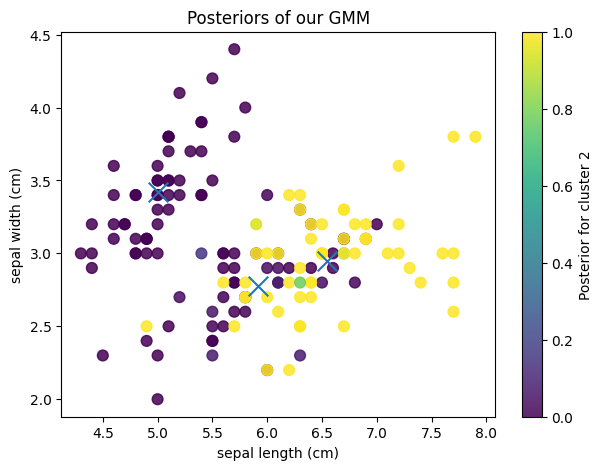

In [18]:
f1, f2 = 0, 1
cluster_to_show = 2

plt.figure(figsize=(7,5))
sc = plt.scatter(X[:, f1], X[:, f2], c=posteriors[:, cluster_to_show], cmap="viridis", s=60, alpha=0.85)
plt.scatter(cluster_centroids[:, f1], cluster_centroids[:, f2], marker="x", s=200)
plt.colorbar(sc, label=f"Posterior for cluster {cluster_to_show}")
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("Posteriors of our GMM")
plt.show()

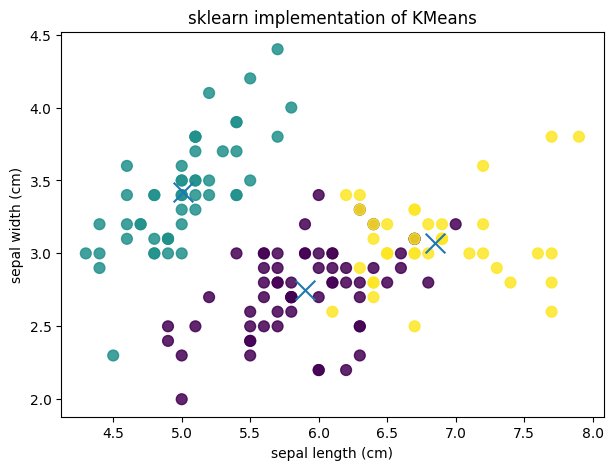

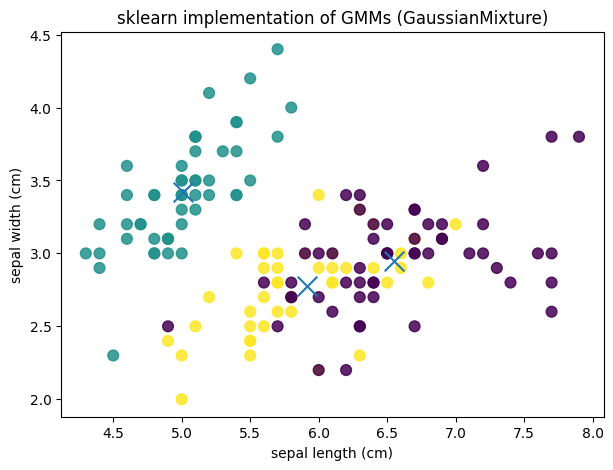

In [19]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

X = data
f1, f2 = 0, 1

# -------------------------
# sklearn KMeans
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
kmeans_labels = kmeans.predict(X)
kmeans_centroids = kmeans.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X[:, f1], X[:, f2], c=kmeans_labels, cmap="viridis", s=60, alpha=0.85)
plt.scatter(kmeans_centroids[:, f1], kmeans_centroids[:, f2], marker="x", s=200)
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("sklearn implementation of KMeans")
plt.show()


# -------------------------
# sklearn Gaussian Mixture Model
# -------------------------
gmm = GaussianMixture(n_components=3, random_state=42, covariance_type="full")
gmm.fit(X)
gmm_labels = gmm.predict(X)
gmm_centroids = gmm.means_

plt.figure(figsize=(7,5))
plt.scatter(X[:, f1], X[:, f2], c=gmm_labels, cmap="viridis", s=60, alpha=0.85)
plt.scatter(gmm_centroids[:, f1], gmm_centroids[:, f2], marker="x", s=200)
plt.xlabel(feature_names[f1])
plt.ylabel(feature_names[f2])
plt.title("sklearn implementation of GMMs (GaussianMixture)")
plt.show()